x0 = k0 r = 0.06283185307179587
Omega/gamma0 = 3017.6307077464335
Omega/omega0 = 3.0176307077464335e-05
omega_minus/gamma0 = 99996982.36929226
omega_plus /gamma0 = 100003017.63070774

Gamma_+(omega-)/gamma0 = 1.9990296653286372
Gamma_+(omega+)/gamma0 = 1.9993915428216846
Gamma_-(omega-)/gamma0 = 0.0007892822925006371
Gamma_-(omega+)/gamma0 = 0.000789520484491657

nbar(omega-) = 0.10000795990423195
nbar(omega+) = 0.09999204078690882

Steady-state populations:
Pee = 0.006944444441666531
Ps  = 0.07638336158702767
Pa  = 0.07639441652965152
Pgg = 0.8402777774416542

Liouvillian gap = 0.0010254774948156072
Slowest relaxation time gamma0*t = 975.1554812812461

Steady detector intensity = 0.16665561205738846

g2(0) = 1.0001326681105087
g2(tau_max) = 1.0000037541027134
analytic g2(0) check = 1.0001326681105074


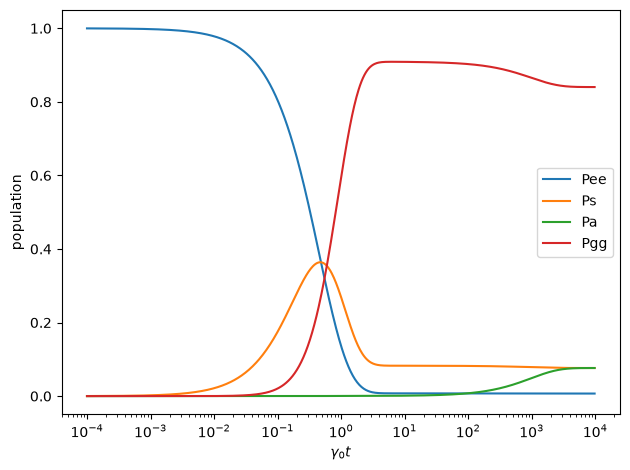

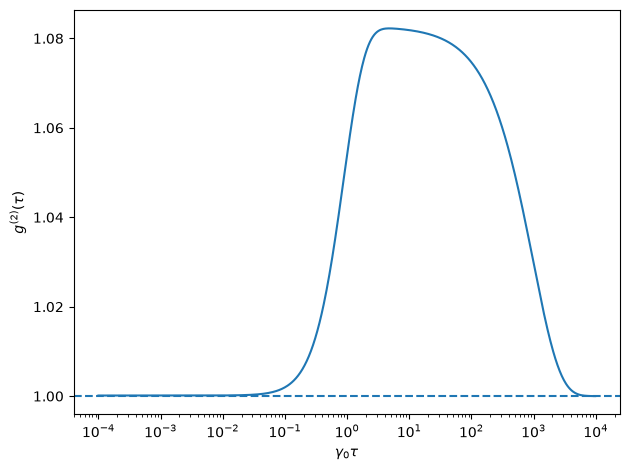

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt


# ============================================================
# 1. PARAMETERS
# ============================================================

# Use gamma0 as the frequency unit:
gamma0 = 1.0

# Realistic optical ratio:
omega0 = 1.0e8          # omega0 / gamma0 = 10^8

# Atomic separation
r_over_lambda = 0.01
x0 = 2.0 * np.pi * r_over_lambda   # k0 r

# u = d_hat . r_hat
# u = 0 : dipoles perpendicular to separation
# u = 1 : dipoles parallel to separation
u = 0.0

# Thermal occupation at omega0.
# Must be > 0 if you want stationary thermal fluorescence.
nbar0 = 0.1

# If None, calculate Omega from the Lehmberg expression.
# Or replace by a number, e.g. 1500.0.
Omega_over_gamma0 = None


# ============================================================
# 2. LEHMBERG FUNCTIONS
# ============================================================

def gamma12_ratio(x, u):
    """
    Gamma12(omega) / Gamma0(omega).

    u = d_hat . r_hat
    """
    u2 = u**2

    return 1.5 * (
        (1.0 - u2) * np.sin(x) / x
        + (1.0 - 3.0*u2)
        * (np.cos(x) / x**2 - np.sin(x) / x**3)
    )


def omega12_ratio(x, u):
    """
    Omega12 / Gamma0 evaluated at omega0.
    """
    u2 = u**2

    return -0.75 * (
        (1.0 - u2) * np.cos(x) / x
        - (1.0 - 3.0*u2)
        * (np.sin(x) / x**2 + np.cos(x) / x**3)
    )


if Omega_over_gamma0 is None:
    Omega = gamma0 * omega12_ratio(x0, u)
else:
    Omega = gamma0 * Omega_over_gamma0


print("x0 = k0 r =", x0)
print("Omega/gamma0 =", Omega / gamma0)
print("Omega/omega0 =", Omega / omega0)


# ============================================================
# 3. DRESSED BOHR FREQUENCIES
# ============================================================

# Energies:
#
# |gg> : -omega0
# |a>  : -Omega
# |s>  : +Omega
# |ee> : +omega0

omega_minus = omega0 - Omega
omega_plus  = omega0 + Omega

if omega_minus <= 0:
    raise ValueError(
        "omega0 - Omega <= 0.  The assumed optical ordering has broken down."
    )

print("omega_minus/gamma0 =", omega_minus)
print("omega_plus /gamma0 =", omega_plus)


# ============================================================
# 4. THERMAL OCCUPATION nbar(omega)
# ============================================================

# nbar0 = 1 / [exp(beta*omega0) - 1]
#
# Hence beta*omega0 = log(1 + 1/nbar0)

if nbar0 > 0:
    beta_omega0 = np.log1p(1.0 / nbar0)
else:
    beta_omega0 = np.inf


def nbar(omega):
    if nbar0 == 0:
        return 0.0

    y = beta_omega0 * omega / omega0

    if y > 700:
        return 0.0

    return 1.0 / np.expm1(y)


# ============================================================
# 5. FREQUENCY-DEPENDENT FREE-SPACE RATES
# ============================================================

def gamma_single(omega):
    """
    Free-space spontaneous emission:
        Gamma0(omega) proportional to omega^3.

    gamma0 = Gamma0(omega0) = 1.
    """
    return gamma0 * (omega / omega0)**3


def gamma12(omega):
    """
    Collective damping evaluated at the actual Bohr frequency.
    """
    x = x0 * omega / omega0

    return gamma_single(omega) * gamma12_ratio(x, u)


def gamma_symmetric(omega):
    value = gamma_single(omega) + gamma12(omega)

    if value < -1e-10:
        raise ValueError("Negative symmetric rate.")

    return max(value, 0.0)


def gamma_antisymmetric(omega):
    value = gamma_single(omega) - gamma12(omega)

    if value < -1e-10:
        raise ValueError("Negative antisymmetric rate.")

    return max(value, 0.0)


# Rates at the two actual Bohr frequencies

Gp_minus = gamma_symmetric(omega_minus)
Gp_plus  = gamma_symmetric(omega_plus)

Gm_minus = gamma_antisymmetric(omega_minus)
Gm_plus  = gamma_antisymmetric(omega_plus)

nm = nbar(omega_minus)
np_ = nbar(omega_plus)

print()
print("Gamma_+(omega-)/gamma0 =", Gp_minus)
print("Gamma_+(omega+)/gamma0 =", Gp_plus)
print("Gamma_-(omega-)/gamma0 =", Gm_minus)
print("Gamma_-(omega+)/gamma0 =", Gm_plus)
print()
print("nbar(omega-) =", nm)
print("nbar(omega+) =", np_)


# ============================================================
# 6. TWO-ATOM BASIS
# ============================================================

# We explicitly define
#
# |e> = |0>
# |g> = |1>
#
# so that sigma_- = |g><e|.
#
# This avoids any convention ambiguity involving destroy(2).

e = qt.basis(2, 0)
g = qt.basis(2, 1)

sm = g * e.dag()
sp = sm.dag()

I = qt.qeye(2)

sm1 = qt.tensor(sm, I)
sm2 = qt.tensor(I, sm)

sp1 = sm1.dag()
sp2 = sm2.dag()

ee = qt.tensor(e, e)
eg = qt.tensor(e, g)
ge = qt.tensor(g, e)
gg = qt.tensor(g, g)

s = (eg + ge).unit()
a = (eg - ge).unit()

Pee = ee * ee.dag()
Ps  = s  * s.dag()
Pa  = a  * a.dag()
Pgg = gg * gg.dag()


# ============================================================
# 7. FREQUENCY-RESOLVED GLOBAL GKSL JUMP OPERATORS
# ============================================================

#
# Symmetric lowering operator:
#
# (sigma1^- + sigma2^-)/sqrt(2)
#
# decomposes as
#
# |s><ee|       frequency omega0 - Omega
# |gg><s|       frequency omega0 + Omega
#

A_s_minus = s  * ee.dag()     # ee -> s
A_s_plus  = gg * s.dag()      # s  -> gg


#
# Antisymmetric lowering operator:
#
# (sigma1^- - sigma2^-)/sqrt(2)
#
# decomposes as
#
# |a><ee|       frequency omega0 + Omega
# |gg><a|       frequency omega0 - Omega
#
# There is an irrelevant minus sign in one matrix element.
#

A_a_plus  = a  * ee.dag()     # ee -> a
A_a_minus = gg * a.dag()      # a  -> gg


# ============================================================
# 8. COLLAPSE OPERATORS
# ============================================================

c_ops = []


def add_thermal_channel(A, Gamma, n):
    """
    Add downward and upward Lindblad channels:

      sqrt[Gamma (n+1)] A
      sqrt[Gamma n]     A^dagger
    """

    if Gamma > 0:
        c_ops.append(np.sqrt(Gamma * (n + 1.0)) * A)

        if n > 0:
            c_ops.append(np.sqrt(Gamma * n) * A.dag())


# Symmetric sector
add_thermal_channel(A_s_minus, Gp_minus, nm)
add_thermal_channel(A_s_plus,  Gp_plus,  np_)

# Antisymmetric sector
add_thermal_channel(A_a_plus,  Gm_plus,  np_)
add_thermal_channel(A_a_minus, Gm_minus, nm)


# ============================================================
# 9. FULL INTERACTION PICTURE
# ============================================================

# We transformed with respect to the complete H_S.
#
# Therefore:
#
#        H_interaction = 0
#
# Neither omega0 nor Omega appears in the propagation.

H_I = 0 * sm1


# ============================================================
# 10. STEADY STATE
# ============================================================

rho_ss = qt.steadystate(H_I, c_ops)

print()
print("Steady-state populations:")
print("Pee =", np.real(qt.expect(Pee, rho_ss)))
print("Ps  =", np.real(qt.expect(Ps,  rho_ss)))
print("Pa  =", np.real(qt.expect(Pa,  rho_ss)))
print("Pgg =", np.real(qt.expect(Pgg, rho_ss)))


# ============================================================
# 11. LIOUVILLIAN RELAXATION RATES
# ============================================================

# At very small r, Gamma_- can become extremely small.
# That produces a REAL slow subradiant timescale.
#
# Unlike the rapid Omega oscillation, this cannot be transformed away.

L = qt.liouvillian(H_I, c_ops)

lam = np.asarray(L.eigenenergies())

tol = 1.0e-10

decay_rates = -np.real(lam[np.real(lam) < -tol])

if len(decay_rates) > 0:
    gap = np.min(decay_rates)
    tau_relax = 1.0 / gap

    print()
    print("Liouvillian gap =", gap)
    print("Slowest relaxation time gamma0*t =", tau_relax)
else:
    gap = None
    tau_relax = np.inf

    print()
    print("No unique nonzero Liouvillian gap was found.")


# ============================================================
# 12. TIME GRID
# ============================================================

# Time is measured in units:
#
#          tau = gamma0 * t
#
# There is NO need for dt << 1/Omega.
#
# We use a logarithmic output grid because the subradiant
# relaxation can be very long.

if np.isfinite(tau_relax):
    tau_max = max(20.0, 10.0 * tau_relax)
else:
    tau_max = 100.0

taus = np.concatenate(
    ([0.0], np.geomspace(1.0e-4, tau_max, 700))
)


# ============================================================
# 13. EXAMPLE TRANSIENT EVOLUTION
# ============================================================

# Example initial condition
rho0 = Pee

# "diag" diagonalizes the constant Liouvillian and then evaluates
# the exponential rather than stepping through rapid oscillations.

result = qt.mesolve(
    H_I,
    rho0,
    taus,
    c_ops,
    e_ops=[Pee, Ps, Pa, Pgg],
    options={"method": "diag"}
)

p_ee = np.real(result.expect[0])
p_s  = np.real(result.expect[1])
p_a  = np.real(result.expect[2])
p_gg = np.real(result.expect[3])


# ============================================================
# 14. UNRESOLVED D1 + D2 DETECTOR
# ============================================================

#
# Equal optical phase:
#
#       D = D1 + D2
#         = sigma1^- + sigma2^-
#
# Overall collection efficiency cancels from normalized g2.

D = sm1 + sm2

Ndet = D.dag() * D

I_ss = np.real(qt.expect(Ndet, rho_ss))

print()
print("Steady detector intensity =", I_ss)

if I_ss < 1.0e-14:
    raise ValueError(
        "Steady-state intensity is essentially zero. "
        "At T=0 with no drive, stationary g2 is undefined."
    )


# ============================================================
# 15. SECOND-ORDER COHERENCE
# ============================================================

#
# g2(tau) =
#
# < D^dag(0) D^dag(tau) D(tau) D(0) >
# ------------------------------------------------
#              <D^dag D>^2
#
#
# Since
#
# D^dag D = 2 ( |ee><ee| + |s><s| )
#
# it commutes with H_S.
#
# Consequently the interaction-picture calculation below is
# exactly sufficient for the equal-phase D1+D2 detector.
#
# solver="es" uses exponential-series / diagonal evolution.

G2 = qt.correlation_3op_1t(
    H_I,
    rho_ss,
    taus,
    c_ops,
    D.dag(),
    Ndet,
    D,
    solver="es"
)

G2 = np.real(np.asarray(G2))

g2 = G2 / I_ss**2


print()
print("g2(0) =", g2[0])
print("g2(tau_max) =", g2[-1])


# ============================================================
# 16. SIMPLE ANALYTIC CHECK OF g2(0)
# ============================================================

#
# D^2 = 2 sigma1^- sigma2^-
#
# Therefore
#
# <D^dag D^dag D D> = 4 P_ee
#
# and
#
# <D^dag D> = 2(P_ee + P_s).
#

pee_ss = np.real(qt.expect(Pee, rho_ss))
ps_ss  = np.real(qt.expect(Ps, rho_ss))

g2_0_check = pee_ss / (pee_ss + ps_ss)**2

print("analytic g2(0) check =", g2_0_check)


# ============================================================
# 17. PLOTS
# ============================================================

# Populations
plt.figure()

plt.semilogx(taus[1:], p_ee[1:], label="Pee")
plt.semilogx(taus[1:], p_s[1:],  label="Ps")
plt.semilogx(taus[1:], p_a[1:],  label="Pa")
plt.semilogx(taus[1:], p_gg[1:], label="Pgg")

plt.xlabel(r"$\gamma_0 t$")
plt.ylabel("population")
plt.legend()
plt.tight_layout()
plt.show()


# g2
plt.figure()

plt.semilogx(taus[1:], g2[1:])

plt.axhline(1.0, linestyle="--")

plt.xlabel(r"$\gamma_0 \tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")

plt.tight_layout()
plt.show()